In [1]:
#The code in this block comes directly from data_sort_and_split.ipynb instead sclaing is uneccesary as it is not required for Forest models
import pandas as pd
from sklearn.model_selection import train_test_split

heart_data = pd.read_csv("heart.csv")

heart_data['Sex_F'] = heart_data['Sex'].map({'M': 0, 'F': 1})
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].map({'N': 0, 'Y': 1})
heart_data = heart_data.drop(columns=['Sex'])

heart_data['ChestPainType'] = pd.Categorical(heart_data['ChestPainType'], categories=['ASY', 'ATA', 'NAP', 'TA'])
heart_data['RestingECG'] = pd.Categorical(heart_data['RestingECG'], categories=['Normal', 'LVH', 'ST'])
heart_data['ST_Slope'] = pd.Categorical(heart_data['ST_Slope'], categories=['Up', 'Flat', 'Down'])

categorical_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
heart_data = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True, dtype=int)

feature_matrix = heart_data.drop("HeartDisease", axis=1)
target_labels = heart_data["HeartDisease"]

features_train, features_test, targets_train, targets_test = train_test_split(
    feature_matrix,
    target_labels,
    test_size=0.20,
    random_state=42,
    stratify= target_labels
)

In [2]:
from sklearn.ensemble import RandomForestClassifier

# Why: n_estimators=100 builds 100 individual decision trees and combines their predictions,
# which produces a much more stable and accurate result than a single decision tree alone.
# Why: criterion='entropy' measures the quality of each split using information gain,
# allowing each tree to always choose the most informative question to ask about a patient.
# Why: max_depth=10 limits how deep each tree can grow, preventing individual trees from
# memorizing the training data and failing on new patients (overfitting).
# Why: max_features='sqrt' means each tree only sees a random subset of features at each
# split, forcing the trees to be different from each other and reducing overfitting.
# Why: bootstrap=True means each tree is trained on a random sample of patients with
# replacement, which adds diversity across trees and improves generalization.
# Why: class_weight='balanced' ensures the model pays extra attention to heart disease
# patients since our dataset may have more healthy patients than sick ones.
# Why: random_state=42 ensures the model produces the same results every time it is run,
# making our results reproducible and comparable with our teammates.
random_forest_classifier = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=10,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)

# Why: We train the model on 80% of the patients so it can learn patterns without ever
# seeing the test set, preventing data leakage.
random_forest_classifier.fit(features_train, targets_train)

# Why: We test the model on the remaining 20% of patients it has never seen before,
# giving us an honest measure of real-world performance.
predicted_labels = random_forest_classifier.predict(features_test)

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Why: predict_proba gives us the probability of heart disease for each patient rather than
# a hard 0 or 1, which is needed to calculate the ROC-AUC score.
# Why: We take [:, 1] to get only the probability of the positive class (heart disease).
predicted_proba = random_forest_classifier.predict_proba(features_test)[:, 1]

# Why: Accuracy alone can be misleading in medical classification — a model that predicts
# no heart disease for every patient would still score high on accuracy but catch nobody.
accuracy  = accuracy_score(targets_test, predicted_labels)

# Why: Precision measures how reliable our positive predictions are — of all patients we
# flagged as having heart disease, how many actually do.
precision = precision_score(targets_test, predicted_labels)

# Why: Recall measures how well we detect true heart disease cases — of all patients who
# actually have heart disease, how many did we correctly catch. This is our most important
# metric since missing a real heart disease patient is far more dangerous than a false alarm.
recall    = recall_score(targets_test, predicted_labels)

# Why: F1-score combines precision and recall into one measure, giving us a balance between
# catching heart disease patients and avoiding too many false alarms.
f1        = f1_score(targets_test, predicted_labels)

# Why: ROC-AUC uses probabilities rather than hard predictions to measure how well the model
# separates heart disease patients from healthy ones across all possible thresholds.
roc_auc   = roc_auc_score(targets_test, predicted_proba)

print("Random Forest Model Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

Random Forest Model Performance:
  Accuracy:  0.9022
  Precision: 0.9038
  Recall:    0.9216
  F1-Score:  0.9126
  ROC-AUC:   0.9424


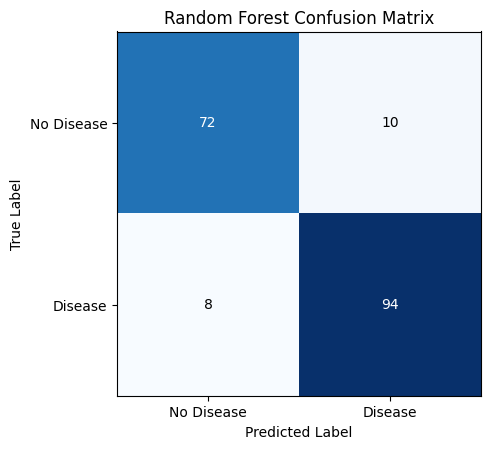

In [7]:
#Confusion Matrix
# Why: The confusion matrix breaks down our predictions into true positives, true negatives,
# false positives, and false negatives, showing us exactly where the model makes mistakes.
# Why: We are most concerned about false negatives where the model misses a real heart
# disease patient, as this is the most dangerous and costly type of error.

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Why: We generate a standard confusion matrix array to identify True/False Positives and Negatives.
cm = confusion_matrix(targets_test, predicted_labels)

# Why: figsize=(5,5) and the 2x2 nature of the data naturally create a square appearance.
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Why: Adding labels to the axes makes the matrix readable for medical professionals.
classes = ['No Disease', 'Disease']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Why: We loop through the matrix to place the actual counts in the center of each square.
# Why: The color 'white' or 'black' is chosen based on the background darkness for contrast.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

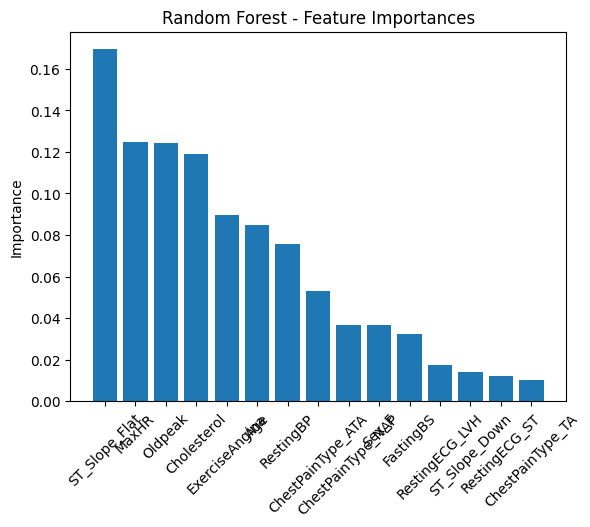

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Why: Random Forest automatically calculates how much each feature contributed to its
# decisions across all 100 trees, giving us a reliable picture of which symptoms matter most.
feature_names = features_train.columns
importances = random_forest_classifier.feature_importances_
indices = np.argsort(importances)[::-1]

# Why: Visualizing feature importances adds medical interpretability, showing which patient
# symptoms and measurements the forest relied on most to predict heart disease.
plt.bar(x=[feature_names[i] for i in indices], height=importances[indices])
plt.title('Random Forest - Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()